# Week 2: Zero-Shot Baseline Evaluation


## Cell 1: Runtime + Drive + login

In [3]:
import torch
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader

from google.colab import drive
drive.mount('/content/drive')

from google.colab import userdata
from huggingface_hub import login
login(token=userdata.get("HF_TOKEN"))
print("Hugging Face login OK")

def vram():
    if not torch.cuda.is_available():
        print("No GPU"); return
    used = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM: {used:.2f}GB / {total:.0f}GB")

Tesla T4, 15360 MiB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Hugging Face login OK


## Cell 2: Install (fast if cached from Week 1)

In [4]:
!pip install -q "lerobot[smolvla,peft]"
!pip install -q pandas pyarrow tqdm

## Cell 3: Load model + dataset + tokenizer

In [5]:
from lerobot.policies.smolvla.modeling_smolvla import SmolVLAPolicy
from lerobot.datasets.lerobot_dataset import LeRobotDataset
from transformers import AutoTokenizer

MODEL_ID = "lerobot/smolvla_base"
DATASET_ID = "lerobot/svla_so100_pickplace"
DEVICE = "cuda"

print("Loading policy...")
policy = SmolVLAPolicy.from_pretrained(MODEL_ID).to(DEVICE).eval()
policy.config.empty_cameras = 1  # dataset has 2 cameras, policy expects 3

print("Loading dataset...")
dataset = LeRobotDataset(DATASET_ID)

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolVLM2-500M-Video-Instruct")

print(f"\nDataset: {dataset.num_episodes} episodes, {dataset.num_frames} frames")
print(f"Policy: {sum(p.numel() for p in policy.parameters())/1e6:.1f}M params")
vram()

Loading policy...


config.json: 0.00B [00:00, ?B/s]

Loading  HuggingFaceTB/SmolVLM2-500M-Video-Instruct weights ...


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


...

model.safetensors:   0%|          | 0.00/907M [00:00<?, ?B/s]

Loading dataset...


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Loading tokenizer...

Dataset: 50 episodes, 19631 frames
Policy: 450.0M params
VRAM: 0.93GB / 16GB


## Cell 4: Build the test split (episodes 40-49)

Episode-level split is critical: if we split randomly across frames, train and test would see frames from the same episodes, which leaks information. Splitting by episode is what serious papers do.

In [6]:
TRAIN_EPISODES = list(range(0, 40))
TEST_EPISODES = list(range(40, 50))

# Find the global frame indices that belong to test episodes
# LeRobotDataset stores episode boundaries in dataset.meta.episodes
test_frame_indices = []
for ep_idx in TEST_EPISODES:
    ep_info = dataset.meta.episodes[ep_idx]
    from_idx = ep_info["dataset_from_index"]
    to_idx = ep_info["dataset_to_index"]
    test_frame_indices.extend(range(from_idx, to_idx))

print(f"Train episodes: {len(TRAIN_EPISODES)} (frames reserved for Week 3)")
print(f"Test episodes: {len(TEST_EPISODES)}")
print(f"Test frames: {len(test_frame_indices)}")

Train episodes: 40 (frames reserved for Week 3)
Test episodes: 10
Test frames: 4032


## Cell 5: Helper — build a batch from a single dataset sample

Encapsulates the schema fixes from Week 1 (image resize, key rename, tokenization, bool mask).

In [7]:
import torch.nn.functional as F

def build_batch(sample, tokenizer, device="cuda", max_tokens=48):
    batch = {}
    for k, v in sample.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.unsqueeze(0).to(device)
        elif isinstance(v, str):
            batch[k] = [v]
        else:
            batch[k] = v

    # Resize + rename images: top → camera1, wrist → camera2
    top = F.interpolate(batch["observation.images.top"], size=(256, 256),
                        mode="bilinear", align_corners=False)
    wrist = F.interpolate(batch["observation.images.wrist"], size=(256, 256),
                          mode="bilinear", align_corners=False)
    batch["observation.images.camera1"] = top
    batch["observation.images.camera2"] = wrist
    del batch["observation.images.top"], batch["observation.images.wrist"]

    # Tokenize language
    task_text = batch["task"][0] if isinstance(batch["task"], list) else batch["task"]
    toks = tokenizer(task_text, padding="max_length", max_length=max_tokens,
                     truncation=True, return_tensors="pt")
    batch["observation.language.tokens"] = toks["input_ids"].to(device)
    batch["observation.language.attention_mask"] = toks["attention_mask"].to(device).bool()

    return batch

# Quick sanity check on one sample
sample = dataset[test_frame_indices[0]]
batch = build_batch(sample, tokenizer)
with torch.no_grad():
    action = policy.select_action(batch)
print(f"Smoke test OK — action shape: {tuple(action.shape)}")

Smoke test OK — action shape: (1, 6)


In [16]:
# ============================================================
# Compute action normalization stats from TRAIN episodes only
# ============================================================
import numpy as np
import torch

print("Computing action normalization stats from train episodes (0-39)...")

train_frame_indices = []
for ep_idx in TRAIN_EPISODES:
    ep_info = dataset.meta.episodes[ep_idx]
    train_frame_indices.extend(range(ep_info["dataset_from_index"], ep_info["dataset_to_index"]))

# Pull all train actions (this is fast, just CPU tensors)
train_actions = np.stack([dataset[i]["action"].numpy() for i in train_frame_indices])
print(f"Train action tensor: {train_actions.shape}")

action_mean = train_actions.mean(axis=0)
action_std = train_actions.std(axis=0) + 1e-6  # epsilon for numerical safety

print(f"Action mean: {action_mean}")
print(f"Action std:  {action_std}")

# Convert to tensors for use in the eval loop
ACTION_MEAN = torch.tensor(action_mean, dtype=torch.float32)
ACTION_STD = torch.tensor(action_std, dtype=torch.float32)

Computing action normalization stats from train episodes (0-39)...
Train action tensor: (15599, 6)
Action mean: [ 12.871589  145.6442    142.079      63.036926   87.75506     7.4869523]
Action std:  [28.638437  36.178158  22.915016  16.742624  11.852008   9.3847065]


## Cell 6: Run inference across the full test split

This is the long-running cell. With ~3-4K test frames and ~0.1s per frame on A100, expect 5-10 minutes.

**Important note on `select_action` and action chunking:** SmolVLA predicts a chunk of 50 actions internally and caches them. Calling `select_action` repeatedly returns one action at a time from the cache. For independent per-frame evaluation we need to reset the action queue between frames, otherwise the policy returns cached actions from a previous observation. We do this by calling `policy.reset()` each iteration.

In [17]:
import numpy as np
from tqdm import tqdm

predictions = []   # predicted action tensors
ground_truths = [] # actual demo actions
metadata = []      # (frame_idx, episode_idx)

# Optional: cap for a fast sanity run. Set to None for full test split.
MAX_FRAMES = None  # e.g., 200 for a quick check

frames_to_eval = test_frame_indices[:MAX_FRAMES] if MAX_FRAMES else test_frame_indices
print(f"Evaluating on {len(frames_to_eval)} frames...\n")

policy.eval()
with torch.no_grad():
    for frame_idx in tqdm(frames_to_eval):
        # Reset action queue so each prediction is independent
        policy.reset()

        sample = dataset[frame_idx]
        batch = build_batch(sample, tokenizer)

        action_pred = policy.select_action(batch)  # (1, action_dim)
        action_gt = sample["action"]  # (action_dim,)

        action_pred_unnorm = action_pred.cpu().squeeze(0) * ACTION_STD + ACTION_MEAN
        predictions.append(action_pred_unnorm.numpy())
        ground_truths.append(action_gt.numpy())
        metadata.append({
            "frame_index": int(sample["frame_index"].item()),
            "episode_index": int(sample["episode_index"].item()),
        })

predictions = np.stack(predictions)
ground_truths = np.stack(ground_truths)

print(f"\nDone. Predictions shape: {predictions.shape}")
vram()

Evaluating on 4032 frames...



100%|██████████| 4032/4032 [46:56<00:00,  1.43it/s]


Done. Predictions shape: (4032, 6)
VRAM: 0.94GB / 16GB


## Cell 7: Compute baseline metrics

Three numbers we care about:
1. **Mean L1 error** — overall predicted-vs-actual deviation.
2. **Per-dimension error** — which action components are easy/hard? (The 6 dims correspond to robot joints + gripper.)
3. **Per-episode error** — does the policy do better on some episodes than others?

In [18]:
import pandas as pd

errors = np.abs(predictions - ground_truths)  # (N, action_dim)
per_frame_l1 = errors.mean(axis=1)             # (N,)
per_dim_l1 = errors.mean(axis=0)               # (action_dim,)

df = pd.DataFrame(metadata)
df["per_frame_l1"] = per_frame_l1
for i in range(predictions.shape[1]):
    df[f"pred_{i}"] = predictions[:, i]
    df[f"gt_{i}"] = ground_truths[:, i]
    df[f"err_{i}"] = errors[:, i]

print("=== BASELINE METRICS ===\n")
print(f"Frames evaluated: {len(df)}")
print(f"Episodes:         {df['episode_index'].nunique()}\n")
print(f"Mean L1 error (all dims, all frames): {errors.mean():.4f}")
print(f"Median L1 error:                       {np.median(per_frame_l1):.4f}")
print(f"L1 std:                                {per_frame_l1.std():.4f}")

print("\nPer-dimension L1 error:")
for i, e in enumerate(per_dim_l1):
    print(f"  dim {i}: {e:.4f}")

print("\nPer-episode mean L1:")
for ep, group in df.groupby("episode_index"):
    print(f"  ep {ep}: {group['per_frame_l1'].mean():.4f}  (n={len(group)})")

=== BASELINE METRICS ===

Frames evaluated: 4032
Episodes:         10

Mean L1 error (all dims, all frames): 22.2843
Median L1 error:                       21.9941
L1 std:                                9.5802

Per-dimension L1 error:
  dim 0: 26.0131
  dim 1: 27.5010
  dim 2: 17.4496
  dim 3: 15.1018
  dim 4: 38.5410
  dim 5: 9.0993

Per-episode mean L1:
  ep 40: 25.0098  (n=473)
  ep 41: 22.9841  (n=475)
  ep 42: 20.4411  (n=417)
  ep 43: 21.3207  (n=423)
  ep 44: 22.6758  (n=367)
  ep 45: 21.0350  (n=351)
  ep 46: 21.0806  (n=346)
  ep 47: 22.4663  (n=418)
  ep 48: 21.5352  (n=361)
  ep 49: 23.4323  (n=401)


## Cell 8: Save predictions + summary to Drive

In [19]:
import json, datetime, os

out_dir = "/content/drive/MyDrive/vla-project/outputs/week2_zero_shot"
os.makedirs(out_dir, exist_ok=True)

# Full per-frame predictions/errors as parquet (fast re-load, small file)
df.to_parquet(f"{out_dir}/predictions.parquet", index=False)

# Summary JSON
summary = {
    "date": datetime.datetime.now().isoformat(),
    "model": MODEL_ID,
    "dataset": DATASET_ID,
    "fine_tuned": False,
    "split": {
        "train_episodes": [min(TRAIN_EPISODES), max(TRAIN_EPISODES)],
        "test_episodes": [min(TEST_EPISODES), max(TEST_EPISODES)],
        "test_frames_evaluated": len(df),
    },
    "metrics": {
        "mean_l1": float(errors.mean()),
        "median_l1": float(np.median(per_frame_l1)),
        "std_l1": float(per_frame_l1.std()),
        "per_dim_l1": [float(x) for x in per_dim_l1],
    },
}

with open(f"{out_dir}/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

# Also update the running project report
report_path = "/content/drive/MyDrive/vla-project/logs/week2_report.json"
with open(report_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"Saved:\n  {out_dir}/predictions.parquet  ({os.path.getsize(out_dir + '/predictions.parquet') / 1024:.1f} KB)")
print(f"  {out_dir}/summary.json")
print(f"  {report_path}")
print("\n=== SUMMARY ===")
print(json.dumps(summary, indent=2))

Saved:
  /content/drive/MyDrive/vla-project/outputs/week2_zero_shot/predictions.parquet  (333.0 KB)
  /content/drive/MyDrive/vla-project/outputs/week2_zero_shot/summary.json
  /content/drive/MyDrive/vla-project/logs/week2_report.json

=== SUMMARY ===
{
  "date": "2026-05-18T19:57:48.241039",
  "model": "lerobot/smolvla_base",
  "dataset": "lerobot/svla_so100_pickplace",
  "fine_tuned": false,
  "split": {
    "train_episodes": [
      0,
      39
    ],
    "test_episodes": [
      40,
      49
    ],
    "test_frames_evaluated": 4032
  },
  "metrics": {
    "mean_l1": 22.284303665161133,
    "median_l1": 21.99405860900879,
    "std_l1": 9.58022689819336,
    "per_dim_l1": [
      26.013057708740234,
      27.500961303710938,
      17.449594497680664,
      15.101805686950684,
      38.541011810302734,
      9.099346160888672
    ]
  }
}


## Cell 9: Quick visualization — error distribution

Plots that go into the writeup later.

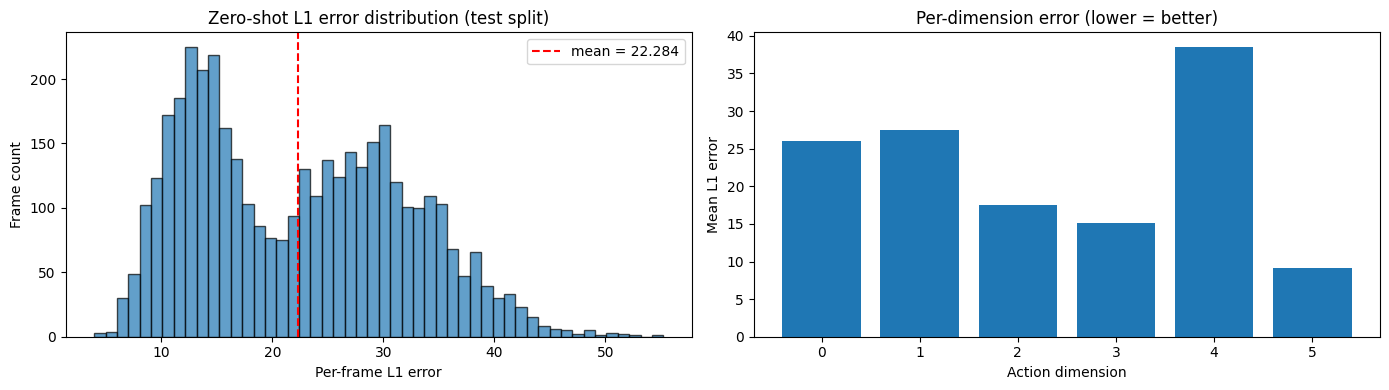


Saved figure: /content/drive/MyDrive/vla-project/outputs/week2_zero_shot/error_distribution.png


In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of per-frame L1 errors
axes[0].hist(per_frame_l1, bins=50, alpha=0.7, edgecolor="black")
axes[0].axvline(per_frame_l1.mean(), color="red", linestyle="--",
                label=f"mean = {per_frame_l1.mean():.3f}")
axes[0].set_xlabel("Per-frame L1 error")
axes[0].set_ylabel("Frame count")
axes[0].set_title("Zero-shot L1 error distribution (test split)")
axes[0].legend()

# Per-dimension error bar plot
axes[1].bar(range(len(per_dim_l1)), per_dim_l1)
axes[1].set_xlabel("Action dimension")
axes[1].set_ylabel("Mean L1 error")
axes[1].set_title("Per-dimension error (lower = better)")

plt.tight_layout()
fig_path = f"{out_dir}/error_distribution.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"\nSaved figure: {fig_path}")

In [12]:
# Are normalization stats loaded?
print("Policy normalization stats:")
if hasattr(policy, "normalize_inputs"):
    print(f"  normalize_inputs: {type(policy.normalize_inputs).__name__}")
if hasattr(policy, "normalize_targets"):
    print(f"  normalize_targets: {type(policy.normalize_targets).__name__}")
if hasattr(policy, "unnormalize_outputs"):
    print(f"  unnormalize_outputs: {type(policy.unnormalize_outputs).__name__}")

# Print the actual stats it's using
for name, module in policy.named_modules():
    if "normalize" in name.lower():
        for buf_name, buf in module.named_buffers():
            print(f"  {name}.{buf_name}: shape={tuple(buf.shape)}, range=[{buf.min().item():.3f}, {buf.max().item():.3f}]")

Policy normalization stats:


In [15]:
import numpy as np

print("Ground-truth action stats (first 100 test frames):")
gt = ground_truths[:100]
for i in range(gt.shape[1]):
    print(f"  dim {i}: min={gt[:,i].min():.2f}, max={gt[:,i].max():.2f}, mean={gt[:,i].mean():.2f}")

print("\nPredicted action stats:")
preds = predictions[:100]
for i in range(preds.shape[1]):
    print(f"  dim {i}: min={preds[:,i].min():.2f}, max={preds[:,i].max():.2f}, mean={preds[:,i].mean():.2f}")

print("\nSample comparison (frame 0):")
print(f"  GT:   {ground_truths[0]}")
print(f"  Pred: {predictions[0]}")

Ground-truth action stats (first 100 test frames):
  dim 0: min=1.85, max=16.88, mean=4.47
  dim 1: min=129.20, max=177.19, mean=169.47
  dim 2: min=132.63, max=164.62, mean=157.94
  dim 3: min=50.27, max=72.07, mean=67.97
  dim 4: min=57.92, max=76.64, mean=72.24
  dim 5: min=0.11, max=9.58, mean=1.24

Predicted action stats:
  dim 0: min=-1.67, max=0.81, mean=-0.51
  dim 1: min=-0.23, max=1.57, mean=0.33
  dim 2: min=-0.65, max=1.94, mean=0.38
  dim 3: min=-0.50, max=0.98, mean=0.20
  dim 4: min=0.04, max=6.70, mean=2.10
  dim 5: min=-0.79, max=2.95, mean=-0.37

Sample comparison (frame 0):
  GT:   [  2.0214844  177.1875     164.61914     72.07031     76.640625
   0.31948882]
  Pred: [-0.8347589   0.563083    0.33812982 -0.09163125  2.8733912  -0.0328252 ]
